# FIG9: Forward-dynamics accuracy of ANNet after adaptation with the inverse-dynamics loss

This notebook regenerates manuscript Figure 9 from the packaged data archive `FIG9.zip` or `FIG9`.
The archive must be in the same folder as this notebook. Every plotted value is read from the archive, and the notebook asserts that no value falls outside the axes, then saves `FIG9.svg`, `FIG9.pdf` and `FIG9.png`.

Saved FIG9.svg
Saved FIG9.pdf


Saved FIG9.png


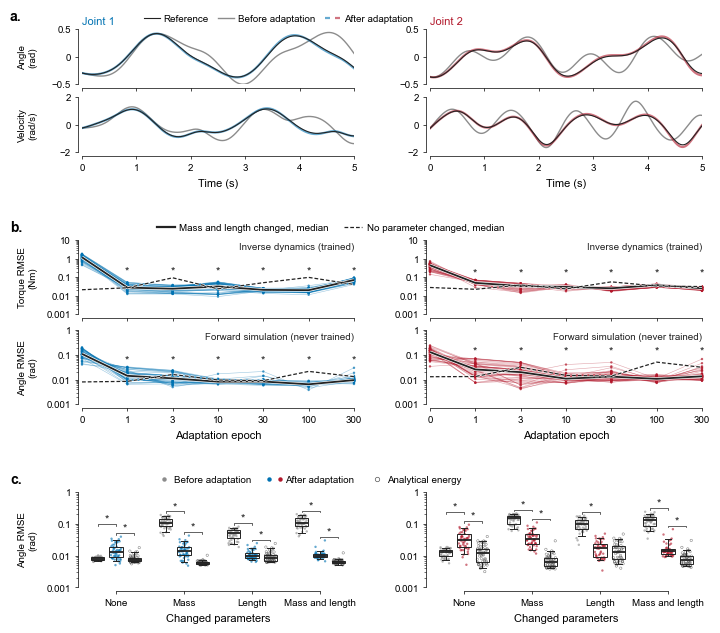

1400 values drawn in panel b (50 trajectories per quantity, joint and epoch; the dashed lines are medians of the plant 'unchanged') and 1200 values in panel c (50 trajectories per plant, condition and joint).
Example trajectory (panel a): index 10 of the 50 trajectories on the plant 'mass_length', 2500 time points; trajectory whose forward errors before and after adaptation lie closest to the medians of the twelve combinations of stage, quantity and joint: smallest sum of |log(error / median error)|.
Plants (m1 and m2 in kg, l1 and l2 in m):
  mass         {'m1': 1.2, 'm2': 0.8, 'l1': 1.0, 'l2': 1.0}
  length       {'m1': 1.0, 'm2': 1.0, 'l1': 0.9, 'l2': 1.1}
  mass_length  {'m1': 1.2, 'm2': 0.8, 'l1': 0.9, 'l2': 1.1}
  unchanged    {'m1': 1.0, 'm2': 1.0, 'l1': 1.0, 'l2': 1.0}
Adaptation: physics-informed loss of Section 3: mean squared error between the gradient of the network with respect to the accelerations and the torques of the perturbed plant; no forward simulation or accelerati

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIG9.zip or FIG9 must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG9.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG9")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG9.zip or FIG9 in the current folder. "
        "Place the data archive in the same folder as FIG9.ipynb."
    )

if DATA_ARCHIVE.is_dir():
    def open_member(name):
        return open(DATA_ARCHIVE / name, "rb")
else:
    _archive = zipfile.ZipFile(DATA_ARCHIVE)

    def open_member(name):
        return _archive.open(name)

# The tables are parsed with exact round-trip precision, so the values equal those the analysis notebook plotted
rmse_table = pd.read_csv(open_member("fig9_rmse_values.csv"), float_precision="round_trip")
stats_table = pd.read_csv(open_member("fig9_statistics.csv"), float_precision="round_trip")
history_table = pd.read_csv(open_member("fig9_adaptation_history.csv"), float_precision="round_trip")
traces_table = pd.read_csv(open_member("fig9_example_traces.csv"), float_precision="round_trip")
metadata = json.load(open_member("fig9_metadata.json"))
figure_plant = metadata["figure"]["plant_of_panels_a_and_b"]
control_plant = metadata["control_plant"]
plant_labels = metadata["plant_labels"]

import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerTuple
from matplotlib.ticker import FuncFormatter, NullFormatter

# -----------------------------------------------------------------------------
# Fig. 9 plotting code (the same drawing in MAIN_RUN_ME_NEW.ipynb and FIG9.ipynb).
# Joint 1 (blue) is on the left and joint 2 (red) on the right in every panel.
# a: example trajectory of the plant with changed masses and lengths: angle and
#    velocity of the reference (dark line) and of the forward simulation with the
#    network before adaptation (grey) and after adaptation (colour).
# b: time course of the adaptation to that plant: trajectory-wise RMSE of the
#    torque (inverse dynamics, the trained quantity) and of the angle (forward
#    simulation, never trained) at the stored epochs. Each thin line is one
#    trajectory, the heavy line joins the medians, and the dashed line joins the
#    medians of the plant with no parameter changed under the same training (control). An asterisk
#    marks an epoch whose errors differ from those at epoch 0 (FDR q < 0.05).
# c: angle RMSE of the forward simulation of every plant before adaptation, after
#    adaptation (last stored epoch) and with the analytical energy, as box plots
#    (median, quartiles, whiskers at the 5th and 95th percentiles, every
#    trajectory as a dot). A bracket with an asterisk joins a condition to the
#    adapted network when their errors differ (FDR q < 0.05).
# No value is removed, and the axes are asserted to enclose every plotted value.
# -----------------------------------------------------------------------------
FIG9_BLUE = '#0072B2'
FIG9_RED = '#B2182B'
FIG9_NEUTRAL = '#222222'
FIG9_BEFORE = '#8C8C8C'
FIG9_ANALYTICAL = '#555555'
FIG9_JOINTS = ['J1', 'J2']
FIG9_JOINT_COLORS = {'J1': FIG9_BLUE, 'J2': FIG9_RED}
# Rows of panel a: column infix in the traces table, axis label
FIG9_TRACE_ROWS = [('q', 'Angle\n(rad)'), ('dq', 'Velocity\n(rad/s)')]
# Rows of panel b: quantity in the RMSE table, axis label, tag, family of comparisons in the statistics table
FIG9_CURVE_ROWS = [('torque', 'Torque RMSE\n(Nm)', 'Inverse dynamics (trained)', 'torque_epoch_vs_before'),
                   ('angle', 'Angle RMSE\n(rad)', 'Forward simulation (never trained)', 'epoch_vs_before')]
# Conditions of panel c: stage in the RMSE table, key label, family of the comparison with the adapted network
FIG9_STAGES = [('before', 'Before adaptation', 'epoch_vs_before'), ('after', 'After adaptation', None),
               ('analytical', 'Analytical energy', 'after_vs_analytical')]
FIG9_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'ytick.minor.size': 1.5,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig9_symmetric_limit(largest):
    # Smallest symmetric axis limit of the form 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8 x 10^k that encloses the data
    for exponent in range(-4, 4):
        for mantissa in (1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0):
            if mantissa * 10.0 ** exponent >= largest:
                return mantissa * 10.0 ** exponent
    raise ValueError('value outside the supported range')


def fig9_decade_range(lowest, highest):
    # Powers of ten that enclose the values
    return 10.0 ** np.floor(np.log10(lowest)), 10.0 ** np.ceil(np.log10(highest))


def fig9_number(value, _=None):
    return f"{value:,g}".replace('-', '−')


def draw_fig9(rmse_table, stats_table, traces_table, figure_plant, control_plant, plant_labels):
    """
    rmse_table:    long-form table with columns task, plant, energy, epoch, stage, quantity, joint, trajectory, rmse.
    stats_table:   one row per comparison with the columns family, plant, quantity, joint, epoch_a and significant_fdr_0_05.
    traces_table:  one row per time point of the example trajectory with the columns time_s and
                   <reference, before, after>_<q, dq>_<j1, j2>.
    figure_plant:  plant of panels a and b (key in the column `plant`).
    control_plant: unchanged plant that received the same training (its comparisons are in the families with the prefix
                   `control_`).
    plant_labels:  ordered mapping from the plant keys of panel c to their axis labels.
    Returns the matplotlib figure (three panels, double-column width).
    """
    def select(plant, quantity, joint, stage=None, epoch=None):
        mask = (rmse_table['plant'] == plant) & (rmse_table['quantity'] == quantity) & (rmse_table['joint'] == joint)
        mask &= (rmse_table['stage'] == stage) if epoch is None else ((rmse_table['energy'] == 'network') & (rmse_table['epoch'] == epoch))
        values = rmse_table.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)
        assert values.size == rmse_table['trajectory'].nunique(), (plant, quantity, joint, stage, epoch)
        return values

    def significant(family, plant, quantity, joint, epoch=None):
        if plant == control_plant and family.endswith('epoch_vs_before'):
            family = 'control_' + family
        mask = ((stats_table['family'] == family) & (stats_table['plant'] == plant) & (stats_table['quantity'] == quantity)
                & (stats_table['joint'] == joint))
        if epoch is not None:
            mask &= (stats_table['epoch_a'] == epoch)
        assert int(mask.sum()) == 1, (family, plant, quantity, joint, epoch)
        return bool(stats_table.loc[mask, 'significant_fdr_0_05'].iloc[0])

    # ---- geometry in inches, measured from the left and from the top of the canvas ----
    width, height = 7.2, 6.5
    left = {'J1': 0.80, 'J2': 4.28}
    span = 2.72
    fig = plt.figure(figsize=(width, height))

    def add_axes(joint, top, tall):
        ax = fig.add_axes([left[joint] / width, 1.0 - (top + tall) / height, span / width, tall / height])
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
        ax.yaxis.set_major_formatter(FuncFormatter(fig9_number))
        ax.xaxis.set_major_formatter(FuncFormatter(fig9_number))
        return ax

    def log_axis(ax, low, high):
        decades = 10.0 ** np.arange(np.log10(low), np.log10(high) + 0.5)
        ax.set_yscale('log')
        ax.set_ylim(low, high)
        ax.set_yticks(decades)
        ax.set_yticks(np.concatenate([decade * np.arange(2, 10) for decade in decades[:-1]]), minor=True)
        ax.yaxis.set_major_formatter(FuncFormatter(fig9_number))
        ax.yaxis.set_minor_formatter(NullFormatter())

    def joint_tag(ax, joint, inside=True):
        ax.text(0.0 if not inside else 0.02, 1.06 if not inside else 0.97, f"Joint {joint[1]}", transform=ax.transAxes, ha='left',
                va='bottom' if not inside else 'top', fontsize=8, color=FIG9_JOINT_COLORS[joint])

    def y_label(ax, label):
        ax.set_ylabel(label, fontsize=7, labelpad=3)
        ax.yaxis.set_label_coords(-0.165, 0.5)

    median_style = dict(color=FIG9_NEUTRAL, lw=1.3, solid_capstyle='butt',
                        path_effects=[pe.withStroke(linewidth=2.3, foreground='white')])
    marks = []

    # ---- a: example trajectory, reference and forward simulation before and after adaptation ----
    time = traces_table['time_s'].to_numpy(dtype=float)
    a_top, a_row, a_gap = 0.42, 0.55, 0.13
    for row, (name, label) in enumerate(FIG9_TRACE_ROWS):
        # The traces are stored in single precision; one axis range for both joints
        traces = {(joint, source): traces_table[f"{source}_{name}_{joint.lower()}"].to_numpy(dtype=np.float32).astype(float)
                  for joint in FIG9_JOINTS for source in ('reference', 'before', 'after')}
        largest = max(np.abs(values).max() for values in traces.values())
        limit = fig9_symmetric_limit(largest)
        assert largest <= limit
        for joint in FIG9_JOINTS:
            ax = add_axes(joint, a_top + row * (a_row + a_gap), a_row)
            ax.plot(time, traces[(joint, 'before')], color=FIG9_BEFORE, lw=1.0, zorder=2)
            ax.plot(time, traces[(joint, 'after')], color=FIG9_JOINT_COLORS[joint], lw=1.6, alpha=0.6, zorder=3)
            ax.plot(time, traces[(joint, 'reference')], color=FIG9_NEUTRAL, lw=0.8, zorder=4)
            ax.set_xlim(time[0], 5.0)
            ax.set_ylim(-limit, limit)
            ax.set_xticks(np.arange(0.0, 5.5, 1.0))
            ax.set_yticks([-limit, 0, limit])
            if row < len(FIG9_TRACE_ROWS) - 1:
                ax.tick_params(labelbottom=False)
                joint_tag(ax, joint, inside=False)
            else:
                ax.set_xlabel('Time (s)')
            if joint == 'J1':
                y_label(ax, label)
    fig.legend(handles=[Line2D([0], [0], color=FIG9_NEUTRAL, lw=0.8), Line2D([0], [0], color=FIG9_BEFORE, lw=1.0),
                        (Line2D([0], [0], color=FIG9_BLUE, lw=1.6, alpha=0.6, solid_capstyle='butt'),
                         Line2D([0], [0], color=FIG9_RED, lw=1.6, alpha=0.6, solid_capstyle='butt'))],
               labels=['Reference', 'Before adaptation', 'After adaptation'],
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)}, loc='lower left',
               bbox_to_anchor=((left['J1'] + 0.62) / width, 1.0 - (a_top - 0.06) / height), ncol=3, frameon=False,
               handlelength=1.6, handletextpad=0.4, columnspacing=1.0, borderaxespad=0.0, borderpad=0.0)

    # ---- b: torque error (trained) and forward angle error (never trained) against the adaptation epoch ----
    epochs = sorted(int(epoch) for epoch in rmse_table.loc[(rmse_table['plant'] == figure_plant) & (rmse_table['task'] == 'forward')
                                                           & (rmse_table['energy'] == 'network'), 'epoch'].dropna().unique())
    x_epochs = np.arange(len(epochs), dtype=float)
    final_epoch = epochs[-1]
    b_top = a_top + len(FIG9_TRACE_ROWS) * a_row + (len(FIG9_TRACE_ROWS) - 1) * a_gap + 0.88
    b_row, b_gap = 0.74, 0.16
    for row, (quantity, label, tag, family) in enumerate(FIG9_CURVE_ROWS):
        fans = {joint: np.stack([select(figure_plant, quantity, joint, epoch=epoch) for epoch in epochs]) for joint in FIG9_JOINTS}
        control = {joint: np.asarray([np.median(select(control_plant, quantity, joint, epoch=epoch)) for epoch in epochs]) for joint in FIG9_JOINTS}
        # One axis range for both joints, with head room above the data for the significance marks
        y_low, y_high = fig9_decade_range(min(min(fan.min() for fan in fans.values()), min(line.min() for line in control.values())),
                                          2.6 * max(fan[1:].max() for fan in fans.values()))
        y_high = max(y_high, fig9_decade_range(1.0, max(fan.max() for fan in fans.values()))[1])
        for joint in FIG9_JOINTS:
            color = FIG9_JOINT_COLORS[joint]
            ax = add_axes(joint, b_top + row * (b_row + b_gap), b_row)
            fan = fans[joint]
            assert (fan >= y_low).all() and (fan <= y_high).all() and (control[joint] >= y_low).all() and (control[joint] <= y_high).all()
            for i in range(fan.shape[1]):
                ax.plot(x_epochs, fan[:, i], color=color, lw=0.4, alpha=0.4, zorder=2, clip_on=False)
            ax.scatter(np.repeat(x_epochs, fan.shape[1]), fan.ravel(), color=color, s=3, edgecolors='none', alpha=0.7, zorder=3, clip_on=False)
            ax.plot(x_epochs, np.median(fan, axis=1), zorder=5, clip_on=False, **median_style)
            ax.plot(x_epochs, control[joint], color=FIG9_NEUTRAL, lw=0.9, ls=(0, (3, 1.6)), zorder=6, clip_on=False,
                    path_effects=[pe.withStroke(linewidth=1.9, foreground='white')])
            # Difference from epoch 0 after FDR correction: asterisks on one line above the data of the later epochs
            y_mark = 1.25 * fan[1:].max()
            for k, epoch in enumerate(epochs[1:], start=1):
                if significant(family, figure_plant, quantity, joint, epoch=epoch):
                    marks.append((ax, fan[1:], ax.text(x_epochs[k], y_mark, '*', ha='center', va='bottom', fontsize=8, color=FIG9_NEUTRAL)))
            log_axis(ax, y_low, y_high)
            ax.set_xlim(x_epochs[0], x_epochs[-1])
            ax.set_xticks(x_epochs)
            ax.set_xticklabels([str(epoch) for epoch in epochs])
            if row < len(FIG9_CURVE_ROWS) - 1:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel('Adaptation epoch')
            if joint == 'J1':
                y_label(ax, label)
            ax.text(1.0, 0.97, tag, transform=ax.transAxes, ha='right', va='top', fontsize=7, color=FIG9_NEUTRAL)
    fig.legend(handles=[Line2D([0], [0], color=FIG9_NEUTRAL, lw=1.6), Line2D([0], [0], color=FIG9_NEUTRAL, lw=0.9, ls=(0, (3, 1.6)))],
               labels=['Mass and length changed, median', 'No parameter changed, median'], loc='lower left',
               bbox_to_anchor=((left['J1'] + 0.75) / width, 1.0 - (b_top - 0.08) / height), ncol=2, frameon=False,
               handlelength=1.8, handletextpad=0.5, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- c: forward angle error of every plant before adaptation, after adaptation and with the analytical energy ----
    c_top = b_top + len(FIG9_CURVE_ROWS) * b_row + (len(FIG9_CURVE_ROWS) - 1) * b_gap + 0.88
    c_row = 0.95
    plants = list(plant_labels)
    offsets = dict(zip([stage for stage, _, _ in FIG9_STAGES], np.linspace(-0.27, 0.27, len(FIG9_STAGES))))
    boxes_values = {(joint, plant, stage): select(plant, 'angle', joint, stage=stage)
                    for joint in FIG9_JOINTS for plant in plants for stage, _, _ in FIG9_STAGES}
    y_low, y_high = fig9_decade_range(min(values.min() for values in boxes_values.values()),
                                      4.0 * max(values.max() for values in boxes_values.values()))
    for joint in FIG9_JOINTS:
        color = FIG9_JOINT_COLORS[joint]
        ax = add_axes(joint, c_top, c_row)
        stage_colors = {'before': FIG9_BEFORE, 'after': color, 'analytical': FIG9_ANALYTICAL}
        for p, plant in enumerate(plants):
            for stage, _, _ in FIG9_STAGES:
                values = boxes_values[(joint, plant, stage)]
                assert (values >= y_low).all() and (values <= y_high).all()
                # Centre line, median; box, quartiles; whiskers, 5th and 95th percentiles
                low, q1, median, q3, high = np.percentile(values, [5, 25, 50, 75, 95])
                ax.bxp([dict(whislo=low, q1=q1, med=median, q3=q3, whishi=high, fliers=[])], positions=[p + offsets[stage]], widths=0.2,
                       showfliers=False, patch_artist=True, manage_ticks=False, zorder=4,
                       boxprops=dict(facecolor='none', edgecolor=FIG9_NEUTRAL, linewidth=0.7),
                       whiskerprops=dict(color=FIG9_NEUTRAL, linewidth=0.7), capprops=dict(color=FIG9_NEUTRAL, linewidth=0.7),
                       medianprops=dict(color=FIG9_NEUTRAL, linewidth=1.3, solid_capstyle='butt'))
                # Every trajectory, spread horizontally inside the box in the order of the test set
                spread = (np.arange(len(values)) / (len(values) - 1) - 0.5) * 0.15
                if stage == 'analytical':
                    # Open circles, so that the analytical energy is told apart from the grey of the network before adaptation
                    ax.scatter(p + offsets[stage] + spread, values, facecolors='none', edgecolors=stage_colors[stage], linewidths=0.35, s=3,
                               alpha=0.8, zorder=3, clip_on=False)
                else:
                    ax.scatter(p + offsets[stage] + spread, values, color=stage_colors[stage], s=3, edgecolors='none', alpha=0.6, zorder=3, clip_on=False)
            # Difference from the adapted network after FDR correction: a bracket with an asterisk to the compared condition
            after = boxes_values[(joint, plant, 'after')]
            bracket_y = {}
            for stage, _, family in FIG9_STAGES:
                if family is not None and significant(family, plant, 'angle', joint, epoch=final_epoch):
                    bracket_y[stage] = 1.3 * max(boxes_values[(joint, plant, stage)].max(), after.max())
            if len(bracket_y) == 2:
                # Two brackets end above the adapted network: keep the higher one clear of the lower one
                higher = max(bracket_y, key=bracket_y.get)
                lower = min(bracket_y, key=bracket_y.get)
                bracket_y[higher] = max(bracket_y[higher], 1.9 * bracket_y[lower])
            for stage, y in bracket_y.items():
                x_from, x_to = sorted((p + offsets[stage], p + offsets['after']))
                ax.plot([x_from, x_from, x_to, x_to], [y / 1.12, y, y, y / 1.12], color=FIG9_NEUTRAL, lw=0.5, zorder=5, clip_on=False)
                data_below = np.concatenate((boxes_values[(joint, plant, stage)], after))
                marks.append((ax, data_below, ax.text(0.5 * (x_from + x_to), y, '*', ha='center', va='bottom', fontsize=8, color=FIG9_NEUTRAL)))
        log_axis(ax, y_low, y_high)
        ax.set_xlim(-0.5, len(plants) - 0.5)
        ax.set_xticks(np.arange(len(plants)))
        ax.set_xticklabels([plant_labels[plant] for plant in plants])
        ax.spines['bottom'].set_bounds(0, len(plants) - 1)
        ax.set_xlabel('Changed parameters')
        if joint == 'J1':
            y_label(ax, 'Angle RMSE\n(rad)')
    fig.legend(handles=[Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor=FIG9_BEFORE, markeredgecolor='none'),
                        (Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor=FIG9_BLUE, markeredgecolor='none'),
                         Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor=FIG9_RED, markeredgecolor='none')),
                        Line2D([0], [0], marker='o', linestyle='None', markersize=3.2, markerfacecolor='none', markeredgecolor=FIG9_ANALYTICAL,
                               markeredgewidth=0.5)],
               labels=[label for _, label, _ in FIG9_STAGES], handler_map={tuple: HandlerTuple(ndivide=None, pad=0.6)}, loc='lower left',
               bbox_to_anchor=((left['J1'] + 0.75) / width, 1.0 - (c_top - 0.08) / height), ncol=3, frameon=False,
               handlelength=1.5, handletextpad=0.3, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- panel labels ----
    for letter, top in (('a.', a_top), ('b.', b_top), ('c.', c_top)):
        fig.text(0.08 / width, 1.0 - (top - 0.06) / height, letter, fontsize=10, fontweight='bold', ha='left', va='bottom')

    # The significance marks must stay inside the axes and above the data
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, values, mark in marks:
        box = mark.get_window_extent(renderer).transformed(ax.transData.inverted())
        assert box.y1 <= ax.get_ylim()[1], 'a significance mark leaves the axes'
        assert box.y0 >= values.max(), 'a significance mark meets the data'
    return fig

mpl.rcParams.update(FIG9_RC)
fig = draw_fig9(rmse_table, stats_table, traces_table, figure_plant, control_plant, plant_labels)
for ext in ("svg", "pdf", "png"):
    path = Path(f"FIG9.{ext}")
    fig.savefig(path, facecolor="white")
    print(f"Saved {path}")
plt.show()

# Every archived value of the conditions shown in panels b and c is drawn once
_n = rmse_table["trajectory"].nunique()
_curve = rmse_table[(rmse_table["plant"] == figure_plant) & (rmse_table["energy"] == "network") & rmse_table["epoch"].notna() & rmse_table["quantity"].isin(["torque", "angle"])]
_boxes = rmse_table[rmse_table["plant"].isin(list(plant_labels)) & (rmse_table["quantity"] == "angle") & rmse_table["stage"].isin(["before", "after", "analytical"])]
assert _curve.groupby(["quantity", "joint", "epoch"]).trajectory.nunique().eq(_n).all()
assert _boxes.groupby(["plant", "stage", "joint"]).trajectory.nunique().eq(_n).all() and len(_boxes) == len(plant_labels) * 3 * 2 * _n
print(f"{len(_curve)} values drawn in panel b ({_n} trajectories per quantity, joint and epoch; the dashed "
      f"lines are medians of the plant '{control_plant}') and {len(_boxes)} values in panel c ({_n} trajectories per plant, condition and joint).")
print(f"Example trajectory (panel a): index {metadata['example_trajectory']['index']} of the {_n} trajectories on the plant "
      f"'{figure_plant}', {len(traces_table)} time points; {metadata['example_trajectory']['selection_rule']}.")
print("Plants (m1 and m2 in kg, l1 and l2 in m):")
for _key, _plant in metadata["plants"].items():
    print(f"  {_key:<12} {_plant}")
print(f"Adaptation: {metadata['adaptation']['loss']}; {metadata['adaptation']['samples']} samples, "
      f"{metadata['adaptation']['epochs']} epochs, {metadata['adaptation']['optimizer']}, learning rate "
      f"{metadata['adaptation']['learning_rate']:.6g}, batch size {metadata['adaptation']['batch_size']}.")
print("Median RMSE of the forward simulation and of the torque (inverse dynamics) by plant and condition:")
_main = rmse_table[rmse_table["stage"].isin(["not_updated", "before", "after", "analytical"])]
print(_main.groupby(["plant", "quantity", "unit", "joint", "stage"], sort=False).rmse.median().unstack("stage").to_string())
print("Median RMSE at the stored epochs of the adaptation:")
_epochs = rmse_table[(rmse_table["energy"] == "network") & rmse_table["epoch"].notna()]
print(_epochs.groupby(["plant", "quantity", "joint", "epoch"], sort=False).rmse.median().unstack("epoch").to_string())
for _family, _table in stats_table.groupby("family", sort=False):
    print(f"Family '{_family}': {metadata['statistics']['family_descriptions'][_family]} (primary test, FDR-adjusted across {len(_table)} comparisons; {int(_table['significant_fdr_0_05'].sum())} significant):")
    print(_table[["plant", "quantity", "joint_label", "group_a", "group_b", "test_name", "p_value", "fdr_q_value", "significant_fdr_0_05",
                  "median_a", "median_b", "median_ratio_a_over_b", "wilcoxon_paired_fdr_q_value", "n_a_lower"]].to_string(index=False))
